## Punto 4.

Se sabe que la tasa de cambio de la población de cierta especie (en miles) está dada por la ecuación

$$\dfrac{dP}{dt} = 3P - 2P^2 \qquad t \text{ en años}$$

A continuación se resuelven los literales a) a e).

---

### Inciso (a) 
> Use el diagrama de fase de la ecuación para determinar el comportamiento de la población de la especie

Los puntos críticos se obtienen igualando $\dfrac{dP}{dt}$ a cero:

$$3P - 2P^2 = P(3-2P) = 0 \;\Rightarrow\; P = 0 \quad \text{o} \quad P = \dfrac{3}{2}$$

Analicemos el signo de $P(3-2P)$ en los tres intervalos que definen estos puntos críticos:

| Intervalo        | $P$ | $3-2P$ | $dP/dt = P(3-2P)$ | Comportamiento |
|-------------------|-----|--------|--------------------|----------------|
| $P<0$             |  $-$ |  $+$   |  $-$               | decrece        |
| $0<P<3/2$         |  $+$ |  $+$   |  $+$               | crece          |
| $P>3/2$           |  $+$ |  $-$   |  $-$               | decrece        |

Por lo tanto:
* $P=0$ es un punto crítico **inestable** (las trayectorias se alejan de él a ambos lados).
* $P=\tfrac{3}{2}$ es un punto crítico **estable** (las trayectorias convergen hacia él desde ambos lados).

Representamos gráficamente el signo de $dP/dt$ y la dirección de las trayectorias alrededor de los puntos críticos $P=0$ y $P=3/2$.

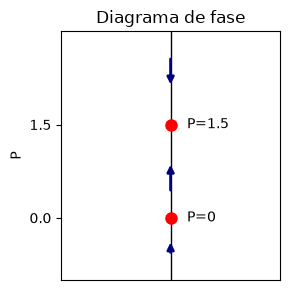

In [1]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(3, 3))

# linea vertical
ax.axvline(0, color='black', linewidth=1)
ax.set_xlim(-1, 1)
ax.set_ylim(-1, 3)

criticos_num = [0, 1.5]
for pc in criticos_num:
    ax.plot(0, pc, 'o', color='red', markersize=8, zorder=3)
    ax.text(0.15, pc, f"P={pc}", va='center')

# flechas indicando la direccion de las trayectorias
regiones = [(-0.75, -1), (0.75, 0.2), (0.75, 1.75)]  
flechas = [
    (0, -0.6, 0, -0.35),   # P<0 decrece 
    (0, 0.4, 0, 0.9),      # 0<P<3/2 crece 
    (0, 2.6, 0, 2.1),      # P>3/2 decrece 
]
for x0, y0, dx, dy in flechas:
    ax.annotate('', xy=(0, dy), xytext=(0, y0),
                arrowprops=dict(arrowstyle='-|>', color='navy', lw=2))

ax.set_yticks(criticos_num)
ax.set_xticks([])
ax.set_ylabel("P")
ax.set_title("Diagrama de fase")
plt.tight_layout()
plt.show()

---

### Inciso (b)   
> Si la población inicial es de 2000, ¿qué ocurre con la población después de mucho tiempo?. Explique

Como $P_0 = 2 > \tfrac{3}{2}$, la condición inicial está en el intervalo donde la función **decrece**. Por lo tanto la población disminuirá y se aproximará asintóticamente a $P=1.5$ (es decir, 1500 individuos) después de mucho tiempo.

---

### Inciso (c)   
> Si ahora se considera que la especie inició con cien especímenes, ¿qué ocurre con la población después
de mucho tiempo?

Como $0 < P_0 = 0.1 < \tfrac{3}{2}$, la condición inicial está en el intervalo donde la función **crece**. Por lo tanto la población aumentará y también se estabilizará en $P=1.5$ (1500 individuos) después de mucho tiempo.

Verifiquemos ambos comportamientos resolviendo la ecuación diferencial numéricamente:

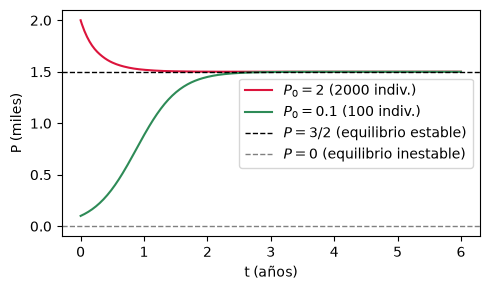

In [2]:
from scipy.integrate import solve_ivp

def modelo(t, P):
    return 3*P - 2*P**2

t_eval = np.linspace(0, 6, 300)

sol_b = solve_ivp(modelo, [0, 6], [2],   t_eval=t_eval)   # P0 = 2   (2000)
sol_c = solve_ivp(modelo, [0, 6], [0.1], t_eval=t_eval)   # P0 = 0.1 (100)

fig, ax = plt.subplots(figsize=(5, 3))
ax.plot(sol_b.t, sol_b.y[0], color='crimson', label='$P_0=2$ (2000 indiv.)')
ax.plot(sol_c.t, sol_c.y[0], color='seagreen', label='$P_0=0.1$ (100 indiv.)')
ax.axhline(1.5, color='black', linestyle='--', linewidth=1, label='$P=3/2$ (equilibrio estable)')
ax.axhline(0, color='gray', linestyle='--', linewidth=1, label='$P=0$ (equilibrio inestable)')
ax.set_xlabel('t (años)')
ax.set_ylabel('P (miles)')
ax.legend()
plt.tight_layout()
plt.show()

---
### Inciso (d)   
> ¿Qué es correcto afirmar de una población de 1500 ejemplares?

Dado que en $P=1500$ tenemos un punto de equilibro estable, podemos concluir que si la población es exactamente de $1500$ ejemplares, la tasa permanecerá constante.

---
### Inciso (e)   
> Mediante análisis se concluye que la tasa de nacimientos es de 150 por cada trimestre y que mueren s
ejemplares en ese mismo periodo, ¿cuál es la ecuación diferencial que describe la tasa de cambio de la
población de la especie anualmente?

Los datos del problema se dan por trimestre:

* **Nacimientos:** 150 por trimestre $\rightarrow$ 600 por año
* **Muertes:** $S$ por trimestre $\rightarrow$ $4S$ por año

La tasa neta de crecimiento anual es:

$$\dfrac{dP}{dt} = 600 - 4S$$

Esta es la **ecuación diferencial anual** que describe el crecimiento de la población en función de la tasa de muertes $S$ (por trimestre).

---

### Inciso (f)   
> Analice el comportamiento de las posibles soluciones, teniendo en cuenta esa tasa de muertes por
trimestre.

De $\dfrac{dP}{dt} = 600 - 4S$, como $S$ es constante, $dP/dt$ también es constante. Entonces:

* Si $600 - 4S > 0$ (es decir $S < 150$): la población **crece indefinidamente**.
* Si $600 - 4S = 0$ (es decir $S = 150$): la población **se mantiene constante**.
* Si $600 - 4S < 0$ (es decir $S > 150$): la población **decrece hasta extinguirse**.

Graficamos $dP/dt$ en función de $S$ para visualizar el punto crítico $S=150$: